# BAUSCIA statistical data analysis

1. Mock a time series of a certain duration containing a chirp signal + noise
2. Select some usefull features
3. Perform cross correlation data analysis

In [2]:
import numpy as np
import sys
sys.path.append('../Notebooks')
from Utilities import plot_settings
import matplotlib.pyplot as plt
from scipy.signal import chirp

In [45]:
def simulate_sample(fs=10000, T=1.0, f_sin=400, t0_range=(0.2, 0.7), dt=0.1, noise_level=0.5, with_burst=True):
    t = np.linspace(0, T, int(fs * T), endpoint=False)
    burst = np.zeros_like(t)

    if with_burst:
        t0 = np.random.uniform(*t0_range)
        mask = (t >= t0) & (t < t0 + dt)
        burst[mask] = np.sin(2 * np.pi * f_sin * (t[mask] - t0))
    else:
        t0 = None  # no burst
    
    noise = np.random.normal(0, noise_level, size=t.shape)
    signal = burst + noise
    return t, signal, with_burst, t0

In [46]:
X = []
y = []
for _ in range(100):
    t, signal, label, _ = simulate_sample(with_burst=np.random.rand() > 0.5)
    X.append(signal)
    y.append(label)
X = np.array(X)
y = np.array(y)

In [47]:
from scipy.stats import kurtosis, skew
from scipy.signal import welch

def extract_features(window, fs=10000):
    features = []

    # Time domain
    features.append(np.mean(window))
    features.append(np.std(window))
    features.append(np.max(window))
    features.append(np.min(window))
    features.append(np.median(window))
    features.append(np.sum(window**2))                   # Energy
    features.append(np.sqrt(np.mean(window**2)))         # RMS
    features.append(np.ptp(window))                      # Peak-to-peak
    features.append(kurtosis(window))
    features.append(skew(window))
    features.append(np.sum(np.diff(np.sign(window)) != 0))  # Zero crossings

    # Frequency domain
    f, Pxx = welch(window, fs=fs)
    features.append(np.sum(Pxx))                         # Total power
    features.append(f[np.argmax(Pxx)])                   # Peak frequency
    features.append(np.sum(f * Pxx) / np.sum(Pxx))       # Spectral centroid
    for low, high in [(0, 100), (100, 300), (300, 600), (600, 1000)]:
        mask = (f >= low) & (f <= high)
        features.append(np.sum(Pxx[mask]))               # Band power

    return np.array(features)

In [48]:
X_feat_time = []
fs = 10000                # Sampling frequency
win_len = 0.05            # Window length [s]
step_len = 0.01           # Step size [s]

n_win = int(fs * win_len)     # Window length in samples
n_step = int(fs * step_len)   # Step size in samples


for x in X:
    sample_feats = []
    for i in range(0, len(x) - n_win + 1, n_step):
        window = x[i:i + n_win]
        feats = extract_features(window, fs)
        sample_feats.append(feats)
    
    X_feat_time.append(sample_feats)

X_feat_time = np.array(X_feat_time)  # shape: (100, N_windows, N_features)
print("Time-dependent feature shape:", X_feat_time.shape)

Time-dependent feature shape: (100, 96, 18)


In [49]:
from sklearn.feature_selection import SelectKBest, f_classif

N, T, F = X_feat_time.shape
X_flat = X_feat_time.reshape(N * T, F)  # shape: (N*T, F)

# Repeat labels for each time window
y_repeated = np.repeat(y, T)

selector = SelectKBest(f_classif, k=10)
X_sel = selector.fit_transform(X_flat, y_repeated)
selected_features = selector.get_support(indices=True)

# Reshape back to (N, T, k)
X_feat_sel = X_sel.reshape(N, T, -1)
print("Selected features shape:", X_feat_sel.shape)


Selected features shape: (100, 96, 10)


In [66]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

# === MOCK DATA (replace with your X_feat_sel: shape (N, T, F)) ===
N, T, F = 100, 96, 10
np.random.seed(42)
X_feat_sel = np.random.randn(N, T, F) * 10 + 5  # example unscaled data

# === SCALE DATA ===
X_reshaped = X_feat_sel.reshape(-1, F)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped).reshape(N, T, F)

# === CREATE TORCH DATASET ===
X_torch = torch.tensor(X_scaled, dtype=torch.float32)
dataset = TensorDataset(X_torch)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

# === MODEL DEFINITION ===
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim=32, num_layers=1):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.latent = nn.Linear(hidden_dim, latent_dim)
        self.decoder_input = nn.Linear(latent_dim, hidden_dim)
        self.decoder = nn.LSTM(hidden_dim, input_dim, num_layers, batch_first=True)

    def forward(self, x):
        enc_out, _ = self.encoder(x)       # (B, T, hidden_dim)
        z = self.latent(enc_out)            # (B, T, latent_dim)
        dec_in = self.decoder_input(z)      # (B, T, hidden_dim)
        dec_out, _ = self.decoder(dec_in)   # (B, T, input_dim)
        return dec_out, z

# === TRAIN SETUP ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMAutoencoder(input_dim=F, latent_dim=5, hidden_dim=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

# === TRAIN LOOP ===
epochs = 100
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for (batch,) in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        recon, _ = model(batch)
        loss = loss_fn(recon, batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    if epoch % 10 == 0 or epoch == epochs-1:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

# === EXTRACT ENCODED FEATURES ===
model.eval()
with torch.no_grad():
    _, Z = model(X_torch.to(device))
X_encoded = Z.cpu().numpy()  # shape (N, T, latent_dim)
print("Encoded features shape:", X_encoded.shape)


Epoch 1/100, Loss: 1.048616
Epoch 11/100, Loss: 1.021799
Epoch 21/100, Loss: 1.012480
Epoch 31/100, Loss: 0.996679
Epoch 41/100, Loss: 0.982269
Epoch 51/100, Loss: 0.970968
Epoch 61/100, Loss: 0.947849
Epoch 71/100, Loss: 0.920447
Epoch 81/100, Loss: 0.892920
Epoch 91/100, Loss: 0.863329
Epoch 100/100, Loss: 0.825810
Encoded features shape: (100, 96, 5)


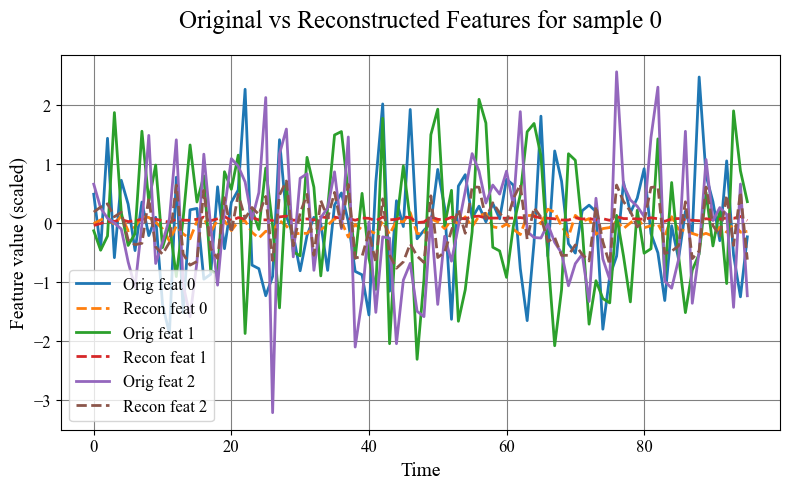

In [67]:
sample_idx = 0
time_idx = 10  # or any time step to inspect
features_to_plot = [0, 1, 2]  # plot 3 features as example

X_orig = X_scaled[sample_idx, time_idx, features_to_plot]
X_recon = model.decoder_input(torch.tensor(X_encoded[sample_idx, time_idx]).float().to(device))
# Actually better to do full reconstruction on that sample:
with torch.no_grad():
    batch_sample = torch.tensor(X_scaled[sample_idx:sample_idx+1]).float().to(device)
    recon_sample, _ = model(batch_sample)
recon_sample = recon_sample.cpu().numpy().squeeze()

plt.figure(figsize=(8,5))
for f in features_to_plot:
    plt.plot(range(T), X_scaled[sample_idx, :, f], label=f"Orig feat {f}")
    plt.plot(range(T), recon_sample[:, f], '--', label=f"Recon feat {f}")
plt.xlabel("Time")
plt.ylabel("Feature value (scaled)")
plt.title(f"Original vs Reconstructed Features for sample {sample_idx}")
plt.legend()
plt.grid(True)
plt.show()


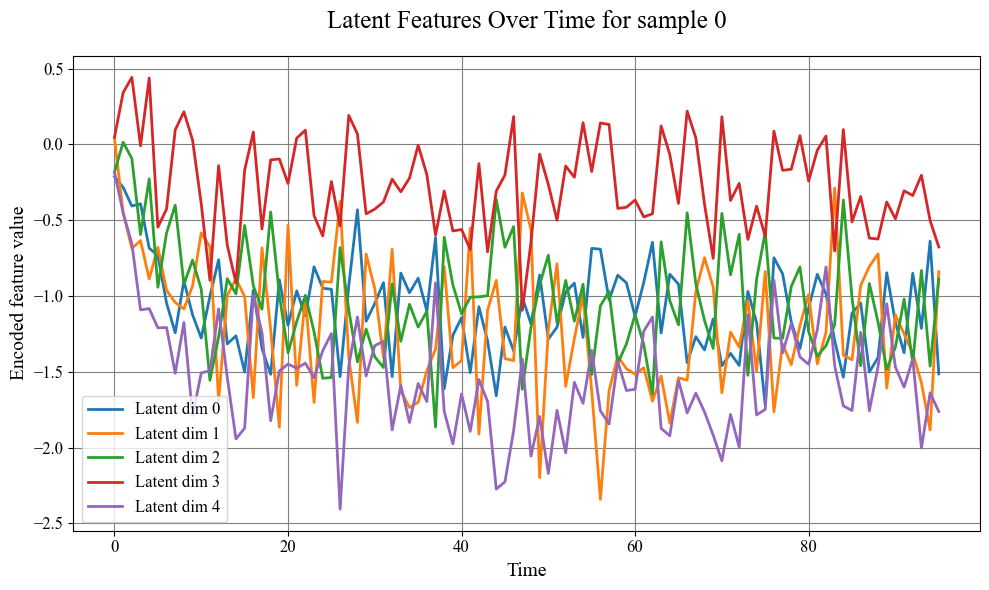

In [68]:
plt.figure(figsize=(10,6))
for d in range(X_encoded.shape[2]):
    plt.plot(range(T), X_encoded[sample_idx, :, d], label=f"Latent dim {d}")
plt.xlabel("Time")
plt.ylabel("Encoded feature value")
plt.title(f"Latent Features Over Time for sample {sample_idx}")
plt.legend()
plt.grid(True)
plt.show()


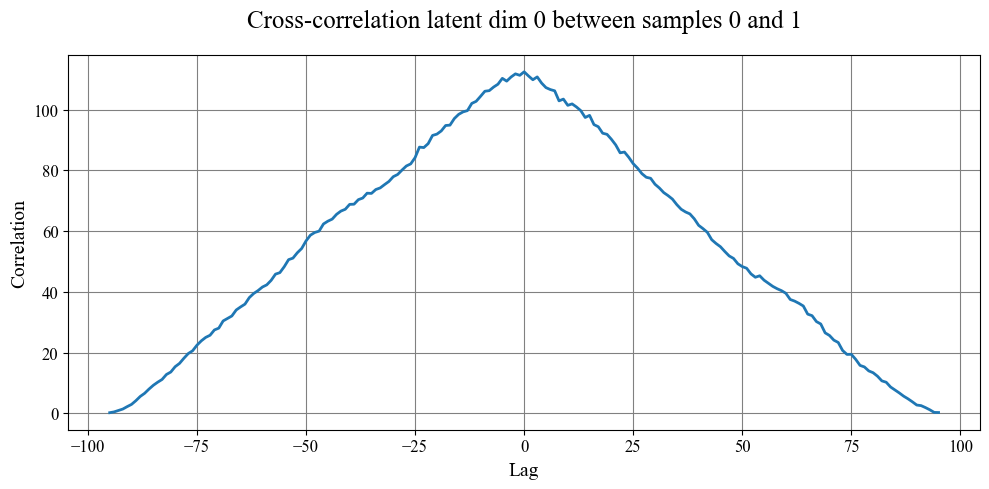

In [70]:
from scipy.signal import correlate
import numpy as np

sample_a, sample_b = 0, 1
latent_dim = 0
signal_a = X_encoded[sample_a, :, latent_dim]
signal_b = X_encoded[sample_b, :, latent_dim]

corr = correlate(signal_a, signal_b, mode='full')
lags = np.arange(-T+1, T)

plt.plot(lags, corr)
plt.title(f"Cross-correlation latent dim {latent_dim} between samples {sample_a} and {sample_b}")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X_pooled, labels, test_size=0.3, random_state=42)

clf = MLPClassifier(hidden_layer_sizes=(32,), max_iter=200)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))